# Imports, Installations and Downloads

In [2]:
%matplotlib inline
import torch as t
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import numpy as np
import seaborn as sns
import random
import matplotlib.pyplot as plt

# Data Processing

This notebook uses the datasets and transforms modules from the torchvision module to extract and transfrom data.

In [3]:
# Define transformer by normalising the data to have zero mean and unit-ish variance
# Use 0.5/0.5 as a common normalisation for single-channel images (values in [0,1])
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert PIL Image to tensor (scales to [0,1])
    transforms.Normalize((0.5,), (0.5,)),   # Normalise to roughly zero-centered
    transforms.Lambda(lambda x: x.flatten())  # Flatten the image to a vector
])

# Install and transform training data
train_dataset = datasets.FashionMNIST(
    root="./data/train",
    train=True,
    download=True,
    transform=transform
)

# Install and transfrom test data
test_dataset = datasets.FashionMNIST(
    root="./data/test",
    train=False,
    download=True,
    transform=transform
)

In [4]:
# Split the train data into train and validation sets (reproducible)
train_size = int((5/6) * len(train_dataset))
val_size = len(train_dataset) - train_size

# Use a fixed seed for reproducibility across runs
SPLIT_SEED = 2
split_generator = t.Generator().manual_seed(SPLIT_SEED)
train_set, val_set = random_split(train_dataset, [train_size, val_size], generator=split_generator)

# Worker seeding function for DataLoader workers to keep transformations deterministic
def _worker_init_fn(worker_id: int):
    # Each worker's seed is derived deterministically from the global seed
    worker_seed = SPLIT_SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    t.manual_seed(worker_seed)

# DataLoader-level generator for deterministic shuffling
dataloader_generator = t.Generator()
dataloader_generator.manual_seed(SPLIT_SEED)

# Define and store the loaders into a global variable
global _LOADERS
_LOADERS = {
    "train": DataLoader(train_set, batch_size=50, shuffle=True, worker_init_fn=_worker_init_fn, generator=dataloader_generator),
    "val": DataLoader(val_set, batch_size=50, worker_init_fn=_worker_init_fn),
    "test": DataLoader(test_dataset, batch_size=50, worker_init_fn=_worker_init_fn)
}

In [5]:
# Check the size of the datasets
print(f"Training data size = {len(_LOADERS["train"].dataset)}")
print(f"Validation data size = {len(_LOADERS["val"].dataset)}")
print(f"Test data size = {len(_LOADERS["test"].dataset)}")

data_batch, labels_batch = next(iter(_LOADERS["train"]))
print(f"Shape of the data batch: {data_batch.shape}")
print(f"Shape of the labels batch: {labels_batch.shape}")

Training data size = 50000
Validation data size = 10000
Test data size = 10000
Shape of the data batch: torch.Size([50, 784])
Shape of the labels batch: torch.Size([50])


# 2. Building and training a Baseline model

In [6]:
class MultiLayerPerceptron(nn.Module):
    def __init__(self, input_dim: int, h1_dim: int, h2_dim: int, num_classes: int):
        """
        Initialises a MultiLayerPerceptron object.
        Parameters:
            input_dim: An int represent the number of features in a data point.
            h1_dim: An int represent the number of neurons in the first hidden layer.
            h2_dim: An int represent the number of neurons in the second hidden layer.
            num_classes: An int represent the number of classes.
        Returns:
            Nothing.
        """
        super(MultiLayerPerceptron, self).__init__()
        # Defining layers of the MultiLayer perceptron
        self.hidden_layer1 = nn.Linear(input_dim, h1_dim)
        self.hidden_layer2 = nn.Linear(h1_dim, h2_dim)
        self.output_layer = nn.Linear(h2_dim, num_classes)
        # Defining the activation functions of hidden layers
        self.h1_relu = nn.ReLU()
        self.h2_relu = nn.ReLU()

    def forward(self, mini_batch: t.Tensor) -> t.Tensor:
        """
        Implements a forward pass for neural network training.
        Parameters:
            mini_batch: A tensor object representing a mini batch of the dataset.
        Returns:
            A tensor object representing the logits of each data point in the mini batch.
        """
        # Pass input through the first hidden dimension and apply ReLu
        h1_out = self.h1_relu(self.hidden_layer1(mini_batch))
        # Pass input through the second hidden dimension and apply ReLu
        h2_out = self.h2_relu(self.hidden_layer2(h1_out))
        # Pass the result through the output layer and return the results
        props = self.output_layer(h2_out)
        return props
    
    def predict(self, mini_batch: t.Tensor) -> t.Tensor:
        """
        Implements a forward pass for neural network training.
        Parameters:
            mini_batch: A tensor object representing a mini batch of the dataset.
        Returns:
            A tensor object representing the predicted class for each data point in the mini batch.
        """
        logits = self.forward(mini_batch)
        return t.argmax(logits, dim=1)

In [7]:
def set_deterministic_seed(seed: int = 2) -> None:
    """
    Set all seeds for deterministic behavior
    Parameters:
        seed: An int representing a seed.
    Returns:
        None.
    """
    t.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # For CUDA machines that have CUDA
    if t.cuda.is_available():
        t.cuda.manual_seed(seed)
        t.cuda.manual_seed_all(seed)
        t.backends.cudnn.deterministic = True
        t.backends.cudnn.benchmark = False


def train_model(
        model: MultiLayerPerceptron,
        criterion: nn.Module,
        optimiser: t.optim.Optimizer,
        num_epochs: int = 50,
        early_stopping: bool = False,
        val_thrs: float = 0.85,
        patience: int = 5
    ) -> dict:
    """
    Implements a training loop.
    Parameters:
        model: A MultiLayerPerceptron object representing a model.
        criterion: An nn.Module representing a loss function.
        optimiser: A t.optim.Optimizer representing an optimiser.
        num_epochs: An int representing the number of epochs the model is to train.
        early_stopping: A bool value used to determining whether or not to use early stopping.
        val_thrs: A float representing the minimum validation accuracy sought for.
        patience: An int representing the number of epochs the validation accuracy is allowed to drop consecutively.
    Returns:
        A dictionary of the training results.
    """
    # Set seed for determinism
    set_deterministic_seed()

    # Track losses and accuracies
    training_loss, validation_loss = [], []
    training_accuracy, validation_accuracy = [], []

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        total_train_loss, correct_train, total_train_samples = 0.0, 0, 0

        # Iterate through the training set batch by batch
        for batch_X, batch_y in _LOADERS["train"]:
            # Forward pass
            outputs = model(batch_X)
            ce_loss = criterion(outputs, batch_y)

            # Reset the gradients and backprop
            optimiser.zero_grad()
            ce_loss.backward()
            optimiser.step()

            # Update total training loss
            total_train_loss += ce_loss.item()

            # Compute accuracy (no_grad not required here because predict does not track grads)
            train_preds = model.predict(batch_X)
            correct_train += (train_preds == batch_y).sum().item()
            total_train_samples += batch_y.size(0)

        avg_train_loss = total_train_loss / len(_LOADERS["train"]) if len(_LOADERS["train"]) > 0 else 0.0
        train_acc = correct_train / total_train_samples if total_train_samples > 0 else 0.0

        # Compute validation loss and accuracy
        total_val_loss, correct_val, total_val_samples = 0.0, 0, 0
        model.eval()
        with t.no_grad():
            for batch_X_val, batch_y_val in _LOADERS["val"]:
                # Forward pass
                outputs_val = model(batch_X_val)
                val_loss = criterion(outputs_val, batch_y_val)
                total_val_loss += val_loss.item()

                # Compute accuracy
                val_preds = model.predict(batch_X_val)
                correct_val += (val_preds == batch_y_val).sum().item()
                total_val_samples += batch_y_val.size(0)

        avg_val_loss = total_val_loss / len(_LOADERS["val"]) if len(_LOADERS["val"]) > 0 else 0.0
        val_acc = correct_val / total_val_samples if total_val_samples > 0 else 0.0

        # Save the metrics
        training_loss.append(round(avg_train_loss, 4))
        validation_loss.append(round(avg_val_loss, 4))
        training_accuracy.append(round(train_acc, 4))
        validation_accuracy.append(round(val_acc, 4))

        if early_stopping:
            if val_acc >= val_thrs:
                break

            if len(validation_accuracy) > 1 and validation_accuracy[-1] < validation_accuracy[-2]:
                epochs_no_improve += 1
            else:
                epochs_no_improve = 0

            if epochs_no_improve >= patience:
                break

    return {
        "Model": model,
        "Training Loss": training_loss,
        "Validation Loss": validation_loss,
        "Training Accuracy": training_accuracy,
        "Validation Accuracy": validation_accuracy
    }


def get_final_metrics(trained_model: MultiLayerPerceptron) -> dict:
    """
    Computes the final training and validation accuracies.
    Parameters:
        trained_model: A MultiLayerPerceptron objected representing the trained model.
    Returns:
        A dictionary of the final training and validation accuracies.
    """
    # Collect data and labels
    train_features, val_features = [], []
    train_labels, val_labels = [], []

    # Iterate over data loaders
    for t_feats, t_labels in _LOADERS["train"]:
        train_features.append(t_feats)
        train_labels.append(t_labels)

    for v_feats, v_labels in _LOADERS["val"]:
        val_features.append(v_feats)
        val_labels.append(v_labels)

    # Concatenate the Batches
    X_train = t.cat(train_features, dim=0)
    X_val = t.cat(val_features, dim=0)
    y_train = t.cat(train_labels, dim=0)
    y_val = t.cat(val_labels, dim=0)

    # Compute accuracies
    trained_model.eval()
    with t.no_grad():
        # Final training accuracy
        final_train_preds = trained_model.predict(X_train)
        final_train_acc = (final_train_preds == y_train).float().mean().item()

        # Final validation accuracy
        final_val_preds = trained_model.predict(X_val)
        final_val_acc = (final_val_preds == y_val).float().mean().item()

    return {
        "Final Train Acc": final_train_acc,
        "Final Val Acc": final_val_acc
    }


def plot_training_results(train_results: dict) -> None:
    """
    Plots the training and validation losses and accuracies from the training results.
    Parameters:
        train_results: A dictionary storing a model's training results.
    Returns:
        None
    """
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    # Left plot
    ax[0].plot(train_results["Training Loss"], marker='o', linestyle='--', color='blue', label='Train Loss')
    ax[0].plot(train_results["Validation Loss"], marker='o', linestyle='--', color='green', label="Val loss")
    ax[0].set_xlabel('Number of epochs')
    ax[0].set_ylabel('Loss (cross-entropy loss)')
    ax[0].set_title("Model Loss over Epochs")
    ax[0].grid(True)
    ax[0].legend()

    # Right plot
    ax[1].plot(train_results["Training Accuracy"], marker='o', linestyle='--', color='red', label='Train Acc')
    ax[1].plot(train_results["Validation Accuracy"], marker='o', linestyle='--', color='orange', label="Val Acc")
    ax[1].set_xlabel('Number of epochs')
    ax[1].set_ylabel('Accuracy (as a percentange)')
    ax[1].set_title("Model Accuracy over Epochs")
    ax[1].grid(True)
    ax[1].legend()
  
    fig.tight_layout()
    plt.show()

In [8]:
"""Training my BaseLIne model"""
# Create an instance of the MultilayeredPerceptron
model = MultiLayerPerceptron(784, 128, 64, 10)
# Define a loss function and an optimiser using lr=0.001
criterion = nn.CrossEntropyLoss()
optimiser = t.optim.Adam(model.parameters(), lr=0.001)

# Train the model
train_results = train_model(model, criterion, optimiser, num_epochs=10)

final_metrics = get_final_metrics(train_results["Model"])

# Display baseline metrics
print(f"Baseline training accuracy = {final_metrics["Final Train Acc"]:.4f}")
print(f"Baseline validation accuracy = {final_metrics["Final Val Acc"]:.4f}")


Baseline training accuracy = 0.9174
Baseline validation accuracy = 0.8876


In [9]:
# Create a DataFrame from the training results lists
data_frame = pd.DataFrame({
    "Training Loss": train_results.get("Training Loss", []),
    "Validation Loss": train_results.get("Validation Loss", []),
    "Training Accuracy": train_results.get("Training Accuracy", []),
    "Validation Accuracy": train_results.get("Validation Accuracy", [])
})
print(data_frame)

   Training Loss  Validation Loss  Training Accuracy  Validation Accuracy
0         0.5266           0.4107             0.8195               0.8505
1         0.3892           0.3873             0.8658               0.8549
2         0.3472           0.3566             0.8808               0.8690
3         0.3218           0.3585             0.8894               0.8687
4         0.3046           0.3483             0.8942               0.8696
5         0.2890           0.3221             0.9013               0.8836
6         0.2743           0.3177             0.9072               0.8866
7         0.2596           0.3679             0.9125               0.8656
8         0.2490           0.3166             0.9156               0.8862
9         0.2422           0.3168             0.9193               0.8876


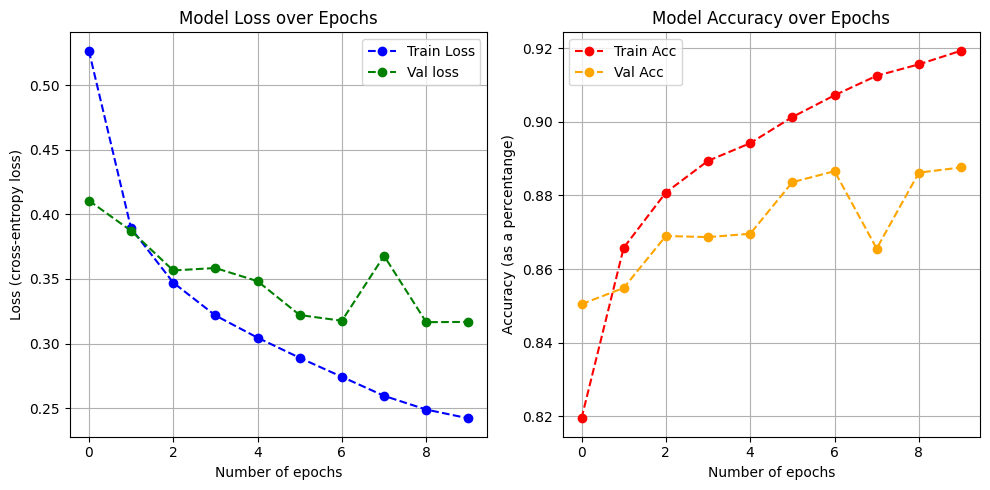

In [10]:
# Display the training results
plot_training_results(train_results)

## 3. Hyperparameter Optimisation Experiment

This notebook investigates the impact of the following hyperparameters on the models performance

* Learning rate = [0.0001, 0.001, 0.01, 0.1]
* Optimiser = [t.optim.Adam, t.optim.SGD, t.optim.RMSprop]
* Number of neurons in hedden layer one = [100, 150, 200, 250]

In [11]:
def grid_search(alphas: list, optimisers: list, num_neurons: list) -> list:
    """
    Implements a grid search for hyperparameter tuning.
    Parameters:
        alphas: A list of learning rates.
        optimisers: A list of strings indicating which optimiser object to create.
        num_neurons: A list on integers representing the number oif neurons in the first hidden layer.
    Returns:
        A list of the training results.
    """
    # Define criterion
    ctrn = nn.CrossEntropyLoss()
    # Store the final accuracies
    accuracies = []
    for neurons in num_neurons:
        model_ = MultiLayerPerceptron(data_batch.shape[1], neurons, 64, 10)
        for opt in optimisers:
            for lr in alphas:
                optimizer = None
                if opt == "Adam":
                    optimizer = t.optim.Adam(model_.parameters(), lr=lr)
                elif opt == "SGD":
                    optimizer = t.optim.SGD(model_.parameters(), lr=lr)
                elif opt == "RMSprop":
                    optimizer = t.optim.RMSprop(model_.parameters(), lr=lr)
                else:
                    raise ValueError("optimiser must be in [\"Adam\", \"SGD\", \"RMSprop\"]")
                
                # Train model
                tr_res = train_model(model_, ctrn, optimizer, num_epochs=10)
                f_metrics = get_final_metrics(tr_res["Model"])
                accuracies.append({
                    "Model": tr_res["Model"],
                    "neurons": neurons,
                    "optimiser": opt,
                    "lr": lr,
                    "Training Loss": tr_res["Training Loss"],
                    "Validation Loss": tr_res["Validation Loss"],
                    "Final Val Acc": f_metrics["Final Val Acc"]
                })
    return accuracies

In [ ]:
# Define tuning hyperparameters
alphas = [0.0001, 0.001, 0.01, 0.1]
optims = ["Adam", "SGD", "RMSprop"]
neurons = [100, 150, 200, 250]

grid_results = grid_search(alphas, optims, neurons)

## 4. Analysis and Report

This notebook uses the for reporting:
* ``matplotlib`` to plot the loss curve for the baseline model and best performing model.
* ``sklearn.metrics`` to define a confusion matrix for the best model's predictions on the validation set.
* ``pandas`` to present experimental results
* ``seaborn`` to clearly compare the hyperparameter impact on performance

In [12]:
# Present the experimental results
grid_res = {
    "neurons": [r["neurons"] for r in grid_results],
    "optimiser": [r["optimiser"] for r in grid_results],
    "lr": [r["lr"] for r in grid_results],
    "Final Val Acc": [r["Final Val Acc"] for r in grid_results],
    "Models": [r["Model"] for r in grid_results]
}

grid_df = pd.DataFrame(grid_res, columns=["neurons", "optimiser","lr", "Final Val Acc"])
# Sort values
sorted_grid_df = grid_df.sort_values(by="Final Val Acc", ascending=False)
print(sorted_grid_df)

    neurons optimiser      lr  Final Val Acc
25      200      Adam  0.0010         0.8850
13      150      Adam  0.0010         0.8844
37      250      Adam  0.0010         0.8816
1       100      Adam  0.0010         0.8798
36      250      Adam  0.0001         0.8775
24      200      Adam  0.0001         0.8753
0       100      Adam  0.0001         0.8731
12      150      Adam  0.0001         0.8725
26      200      Adam  0.0100         0.8653
38      250      Adam  0.0100         0.8605
14      150      Adam  0.0100         0.8579
2       100      Adam  0.0100         0.8516
4       100       SGD  0.0001         0.1024
3       100      Adam  0.1000         0.1024
10      100   RMSprop  0.0100         0.1005
43      250       SGD  0.1000         0.1005
33      200   RMSprop  0.0010         0.0999
40      250       SGD  0.0001         0.0999
41      250       SGD  0.0010         0.0999
39      250      Adam  0.1000         0.0999
34      200   RMSprop  0.0100         0.0998
17      15

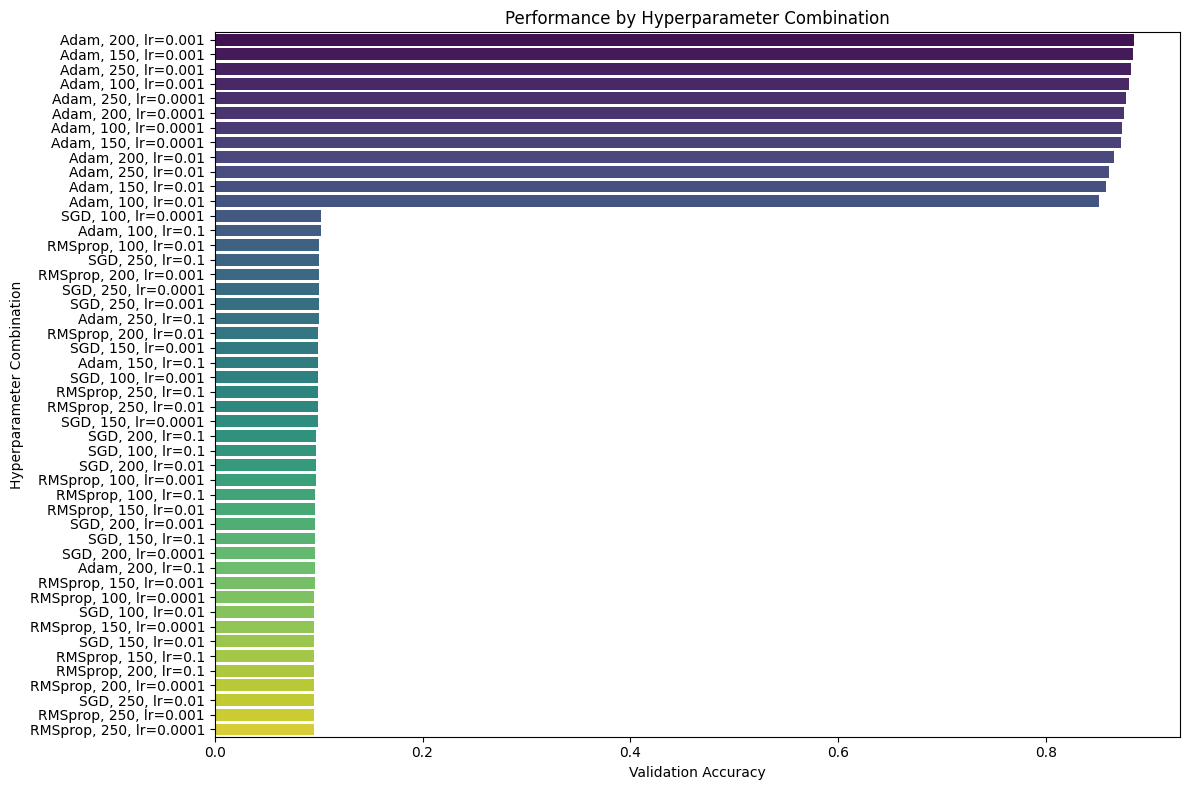

In [13]:
"""Visualise different hyperparameter combinations using barplot"""

# Combine hyperpaameters into one label
grid_df["config"] = grid_df.apply(lambda row: f"{row['optimiser']}, {row['neurons']}, lr={row['lr']}", axis=1)

# SOrt by accuracy
new_grid_df = grid_df.sort_values("Final Val Acc", ascending=False)

# PLot the barchart
plt.figure(figsize=(12,8))
sns.barplot(data=new_grid_df, x="Final Val Acc", y="config", hue="config", palette="viridis", legend=False)
plt.title("Performance by Hyperparameter Combination")
plt.xlabel("Validation Accuracy")
plt.ylabel("Hyperparameter Combination")
plt.tight_layout()
plt.show()

Best grid index = 25, Final Val Acc = 0.8850


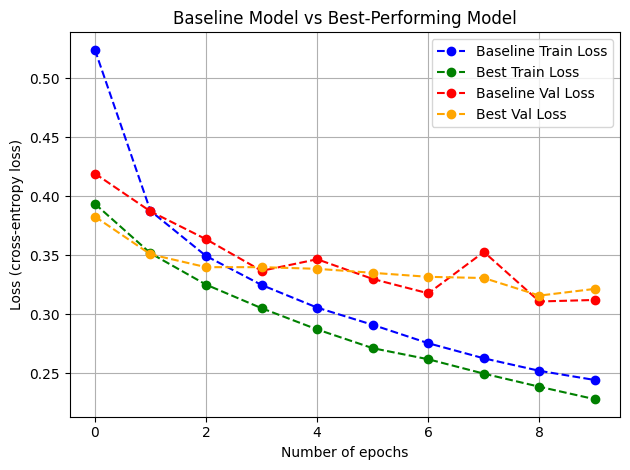

In [14]:
"""Plotting the loss curves of baseline model vs best model"""

# Get the losses of the baseline model
baseline_tr_loss = train_results["Training Loss"]
baseline_val_loss = train_results["Validation Loss"]

# Find best model index from grid_results by validation accuracy
if isinstance(grid_results, list) and len(grid_results) > 0:
    best_idx = max(range(len(grid_results)), key=lambda i: grid_results[i].get("Final Val Acc", 0.0))
    best_model_tr_loss = grid_results[best_idx].get("Training Loss", [])
    best_model_val_loss = grid_results[best_idx].get("Validation Loss", [])
    print(f"Best grid index = {best_idx}, Final Val Acc = {grid_results[best_idx].get('Final Val Acc', 0.0):.4f}")
else:
    best_model_tr_loss = []
    best_model_val_loss = []

# Plot the Loss curves
plt.plot(baseline_tr_loss, marker='o', linestyle='--', color='blue', label='Baseline Train Loss')
plt.plot(best_model_tr_loss, marker='o', linestyle='--', color='green', label="Best Train Loss")
plt.plot(baseline_val_loss, marker='o', linestyle='--', color='red', label="Baseline Val Loss")
plt.plot(best_model_val_loss, marker='o', linestyle='--', color='orange', label="Best Val Loss")
plt.xlabel('Number of epochs')
plt.ylabel('Loss (cross-entropy loss)')
plt.title("Baseline Model vs Best-Performing Model")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

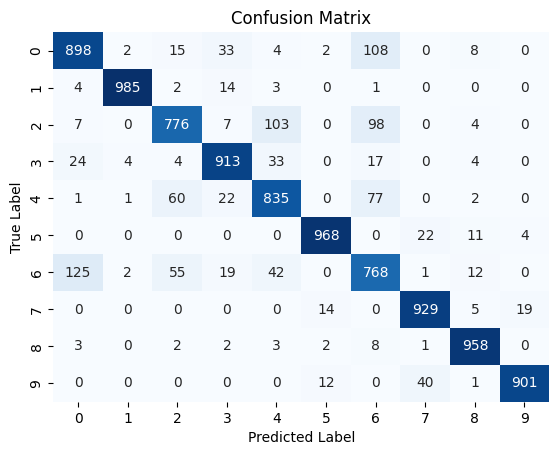

In [17]:
"""Generate and Display a confusion matrix for the best model's predictions"""
# Best configs: 25      200      Adam  0.0010
best_model = MultiLayerPerceptron(784, 200, 64, 10)
optims = t.optim.Adam(best_model.parameters(), lr=0.001)

best_res = train_model(best_model, criterion, optims, num_epochs=10)
_best_model= best_res["Model"]

# Collect data and labels
val_features = [] 
val_labels = []

# Iterate over data loaders

for v_feats, v_label in _LOADERS["val"]:
    val_features.append(v_feats)
    val_labels.append(v_label)

# Concatenate the Batches
X_val = t.cat(val_features, dim=0)
y_val = t.cat(val_labels, dim=0)

# Compute predictions and confusion matrix
_best_model.eval()
with t.no_grad():
    final_val_preds = _best_model.predict(X_val)

cm = confusion_matrix(y_val, final_val_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [1]:

uniqs, u_coutns = y_val.unique(return_counts=True)
print(uniqs)
print(u_coutns)

NameError: name 'y_val' is not defined